scratch implementation of linear **regression**


In [1]:
import numpy as np
import pandas as pd

class LinearRegression_:

  def __init__(self):
    self.theta=None

  def fit(self,X_train,y_train):

    X_train=X_train.copy()
    X_train=np.array(X_train)

    y_train=np.array(y_train)
    # X_train.insert(0,"ones",np.ones(X_train.shape[0]))
    X_train=np.hstack((np.ones((X_train.shape[0],1)),X_train))


    self.theta=np.linalg.solve((X_train.T @ X_train),(X_train.T@ y_train))


  def weight(self):
    return self.theta[1:]

  def predict(self,X_test):

    X_test=X_test.copy()
    X_test=np.asarray(X_test)
    X_test=np.hstack((np.ones((X_test.shape[0],1)),X_test))


    return X_test @ self.theta

  def mean_squared_error(self,X_test,y_test):

    y_test=np.asarray(y_test)
    pred=self.predict(X_test)
    return np.mean((y_test-pred)**2)

  def mean_absolute_error(self,X_test,y_test):

      y_test=np.asarray(y_test)
      pred=self.predict(X_test)
      return np.mean(np.abs(y_test-pred))

  def r2_score(self,X_test,y_test):

      y_test=np.array(y_test)
      rs=np.sum((y_test-self.predict(X_test))**2)
      rt=np.sum((y_test-np.mean(y_test))**2)
      return 1-(rs/rt)

  def score(self,X_test,y_test):
    return self.r2_score(X_test,y_test)

In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("/content/AirQualityUCI.csv",delimiter=';')

df=df.iloc[:,:-2]

# df.columns=df.columns.str.strip()
df["RH"]=df["RH"].str.replace(",",".")
df["T"]=df["T"].str.replace(",",".")
df["AH"]=df["AH"].str.replace(",",".")
df["C6H6(GT)"]=df['C6H6(GT)'].str.replace(",",".")
df['CO(GT)']=df['CO(GT)'].str.replace(",",".")
df["Time"]=df["Time"].str.replace(".",":")

df.dropna(inplace=True)

df["Date"]=pd.to_datetime(df["Date"],format="%d/%m/%Y")
df["Time"]=pd.to_datetime(df["Time"],format='%H:%M:%S', errors='coerce')
df=df.astype({
  "CO(GT)":float,
  "C6H6(GT)":float,
  "T":float,
  "RH":float,
  "AH":float,
})

df.replace(-200,np.nan,inplace=True)

df = df[df["C6H6(GT)"].notna()]
df.dropna(thresh=len(df)*0.4,inplace=True,axis=1)
for col in df.columns:
  if col != "C6H6(GT)":
    df[col]=df[col].fillna(df[col].mean())
df["year"]=df["Date"].dt.year
df["month"]=df["Date"].dt.month
df["day"]=df["Date"].dt.day

df["hour"]=df["Time"].dt.hour
df.drop(columns=["Date","Time"],inplace=True)


import numpy as np
df["month_sin"]=np.sin(2*np.pi*df["month"]/12)
df["month_cos"]=np.cos(2*np.pi*df["month"]/12)

df["day_sin"]=np.sin(2*np.pi*df["day"]/7)
df["day_cos"]=np.cos(2*np.pi*df["day"]/7)

df["hour_sin"]=np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]=np.cos(2*np.pi*df["hour"]/24)

df.drop(columns=["month","day","hour"],inplace=True)




<Axes: >

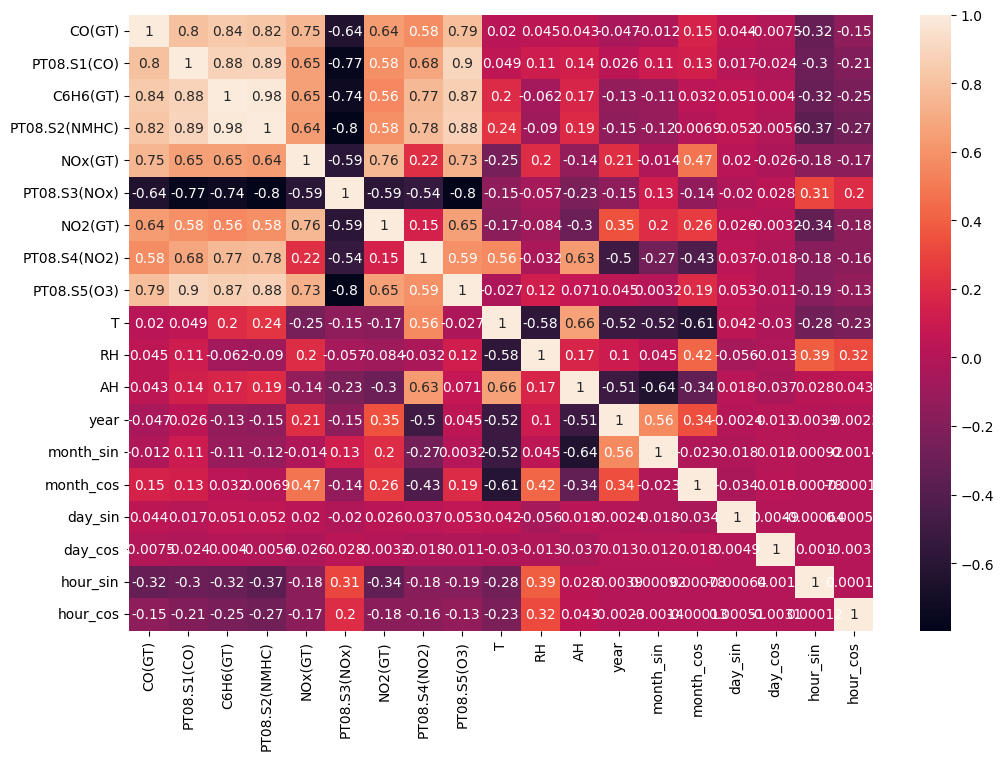

In [3]:
import seaborn as sea
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(12,8))
sea.heatmap(df.corr(),annot=True)

In [4]:
X=df.drop(columns=["C6H6(GT)"])
y=df["C6H6(GT)"]
print(y.head())

0    11.9
1     9.4
2     9.0
3     9.2
4     6.5
Name: C6H6(GT), dtype: float64


In [5]:
# using sklearn model


from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.18,random_state=45)

from scipy.stats import pearsonr
corr={
    feature:pearsonr(X_train[feature],y_train)[0]
    for feature in X.columns
}

corr=pd.DataFrame.from_dict(corr,orient="index",columns=["corr"])
corr.sort_values(by="corr",ascending=False,inplace=True)

corr=corr[corr["corr"]>0.05]

X=X[corr.index]
# X.drop(columns=["PT08.S2(NMHC)"],inplace=True)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.18,random_state=45)
print(corr)
print(X)

                   corr
PT08.S2(NMHC)  0.981740
PT08.S1(CO)    0.882651
PT08.S5(O3)    0.865006
CO(GT)         0.838006
PT08.S4(NO2)   0.765364
NOx(GT)        0.651285
NO2(GT)        0.553952
T              0.200726
AH             0.170459
day_sin        0.050291
      PT08.S2(NMHC)  PT08.S1(CO)  PT08.S5(O3)  CO(GT)  PT08.S4(NO2)  NOx(GT)  \
0            1046.0       1360.0       1268.0     2.6        1692.0    166.0   
1             955.0       1292.0        972.0     2.0        1559.0    103.0   
2             939.0       1402.0       1074.0     2.2        1555.0    131.0   
3             948.0       1376.0       1203.0     2.2        1584.0    172.0   
4             836.0       1272.0       1110.0     1.6        1490.0    131.0   
...             ...          ...          ...     ...           ...      ...   
9352         1101.0       1314.0       1729.0     3.1        1374.0    472.0   
9353         1027.0       1163.0       1269.0     2.4        1264.0    353.0   
9354         106

In [ ]:
# normal method of train test split


# import random
# random.seed(0)
# index=[index for index in df.index]
# random.shuffle(index)
# df=df.loc[index]


# df1=df.iloc[:int(len(df)*0.82)]
# df2=df.iloc[int(len(df)*0.82):]

# X_train,y_train=df1.drop(columns=["C6H6(GT)"]),df1["C6H6(GT)"]
# X_test,y_test=df2.drop(columns=["C6H6(GT)"]),df2["C6H6(GT)"]


# from scipy.stats import pearsonr
# corr={
#     feature:pearsonr(X_train[feature],y_train)[0]
#     for feature in X.columns
# }

# corr=pd.DataFrame.from_dict(corr,orient="index",columns=["corr"])
# corr.sort_values(by="corr",ascending=False,inplace=True)

# corr=corr[corr["corr"]>0.05]

# X=X[corr.index]

# random.seed(0)
# index=[index for index in df.index]
# random.shuffle(index)
# df=df.loc[index]


# df1=df.iloc[:int(len(df)*0.82)]
# df2=df.iloc[int(len(df)*0.82):]

# X_train,y_train=df1.drop(columns=["C6H6(GT)"]),df1["C6H6(GT)"]
# X_test,y_test=df2.drop(columns=["C6H6(GT)"]),df2["C6H6(GT)"]

In [6]:
# Using Linear regression algorithm

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
print(lr.score(X_train,y_train))
print(lr.score(X_test,y_test))


0.9724397445202465
0.9731173382670205


Equal train and test score with both sklearn and scratch method

In [7]:
# Using Linear regression scratch

model=LinearRegression_()
model.fit(X_train,y_train)
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

0.9724397445202465
0.9731173382670205


In [8]:
# Using random forest regressor

from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=300,
                         max_depth=10,
                         min_samples_split=5,
                         random_state=45)
rf.fit(X_train,y_train)
print(rf.score(X_train,y_train))
print(rf.score(X_test,y_test))

0.9999245227651944
0.9999758217613571


In [ ]:
prediction=rf.predict(X_test)

from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,prediction)
print(mse)


from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,prediction)
print(mae)

from sklearn.metrics import r2_score
r2=r2_score(y_test,prediction)
print(r2)


from sklearn.metrics import root_mean_squared_error
rmse=root_mean_squared_error(y_test,prediction)
absolute_r2=1-((1-r2)*(y_test.shape[0]-1)/(y_test.shape[0]-X_test.shape[1]-1))
print(absolute_r2)

2.2951527265691856
0.9951634309842611
0.9603454718797123
0.9601236628349127


cross validation of random forest

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.76264891 0.91938182 0.93718768 0.91744143 0.92900744]
0.8931334579009664


cross val score of linear regression

In [ ]:
from sklearn.model_selection import cross_val_score

score=cross_val_score(lr,
                      X,
                      y,
                      cv=5,
                      scoring="r2")
print(score)
print(score.mean())

[0.59367865 0.93916428 0.86738837 0.92769221 0.81446468]
0.8284776365922522



residual plot

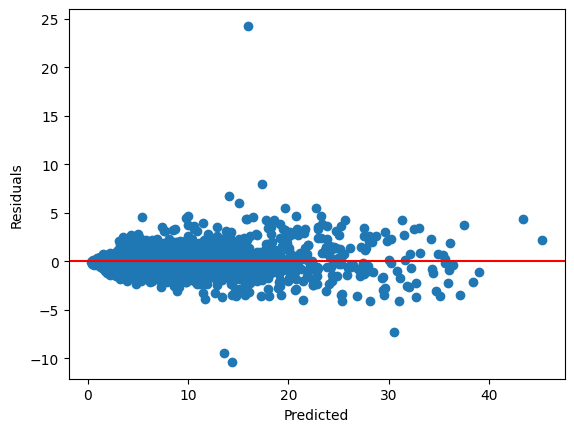

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - prediction

plt.scatter(prediction, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

testing of cyclic data like as month, time

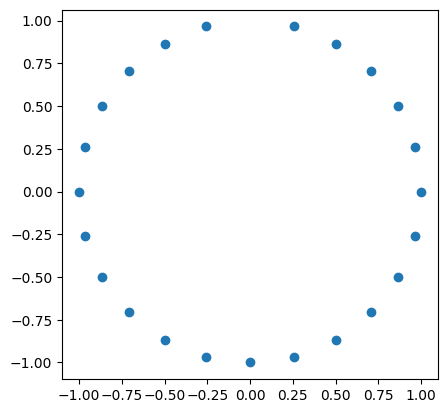

In [ ]:
import numpy as np
month=np.arange(1,24)
angle=2*np.pi*month/24
si=np.sin(angle)
co=np.cos(angle)

import matplotlib.pyplot as plt
plt.gca().set_aspect('equal')
plt.scatter(x=si,y=co)
plt.show()